In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM 

In [2]:
df = pd.read_csv("goog.csv")

In [53]:
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [54]:
df.shape

(61, 6)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    61 non-null     object 
 1   Open    61 non-null     float64
 2   High    61 non-null     float64
 3   Low     61 non-null     float64
 4   Close   61 non-null     float64
 5   Volume  61 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 3.0+ KB


In [3]:
data = df[['Close']].values

In [57]:
data.shape

(61, 1)

In [4]:
scaler = MinMaxScaler()

In [5]:
data_scaled = scaler.fit_transform(data)

In [6]:
#create sequence 
#using previous 10 days
X = []
y = []

time_steps = 10

for i in range(time_steps, len(data_scaled)):
    X.append(data_scaled[i-time_steps : i, 0])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

In [7]:
#reshape for RNN
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)
print(y.shape)

(51, 10, 1)
(51,)


In [8]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [9]:
X_train.shape

(40, 10, 1)

In [10]:
#Build RNN model
model = Sequential()

In [11]:
model.add(
    SimpleRNN(units=100, activation='tanh', input_shape=(X_train.shape[1], 1))
)

c:\Users\HP\anaconda4\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.add(Dense(1))

In [13]:
model.compile(optimizer='adam', loss='mse')

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,301 (40.24 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1547
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0348  
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0432 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0248 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0219 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0194 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0160
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0138 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0114
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0105 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0105 
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096  
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0094 
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0088
Epoch 16/100
5/5

In [16]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step


In [17]:
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

In [18]:
y_pred = scaler.inverse_transform(y_pred)

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

5.646412499904892

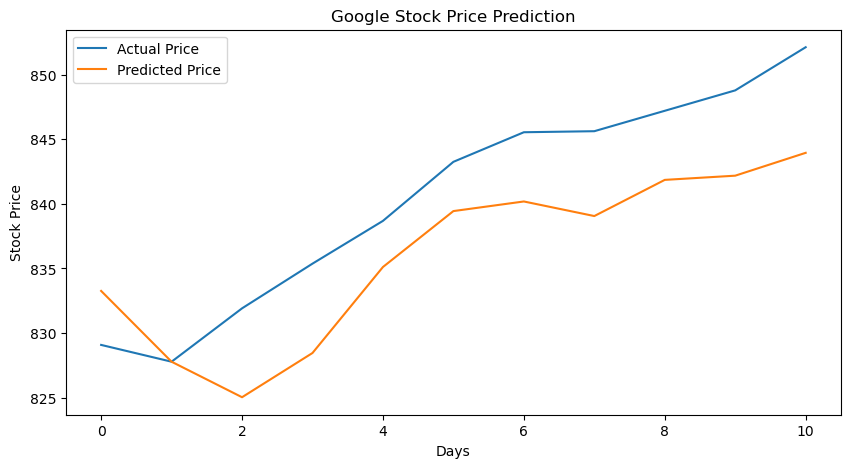

In [21]:
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title("Google Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()
plt.show()